In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 

In [ ]:
df = pd.read_csv('D:\ML\Regression\diabetes(1).csv')

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [13]:
df.duplicated().sum()

np.int64(0)

Pregnancies                    Axes(0.125,0.11;0.0731132x0.77)
Glucose                     Axes(0.212736,0.11;0.0731132x0.77)
BloodPressure               Axes(0.300472,0.11;0.0731132x0.77)
SkinThickness               Axes(0.388208,0.11;0.0731132x0.77)
Insulin                     Axes(0.475943,0.11;0.0731132x0.77)
BMI                         Axes(0.563679,0.11;0.0731132x0.77)
DiabetesPedigreeFunction    Axes(0.651415,0.11;0.0731132x0.77)
Age                         Axes(0.739151,0.11;0.0731132x0.77)
Outcome                     Axes(0.826887,0.11;0.0731132x0.77)
dtype: object

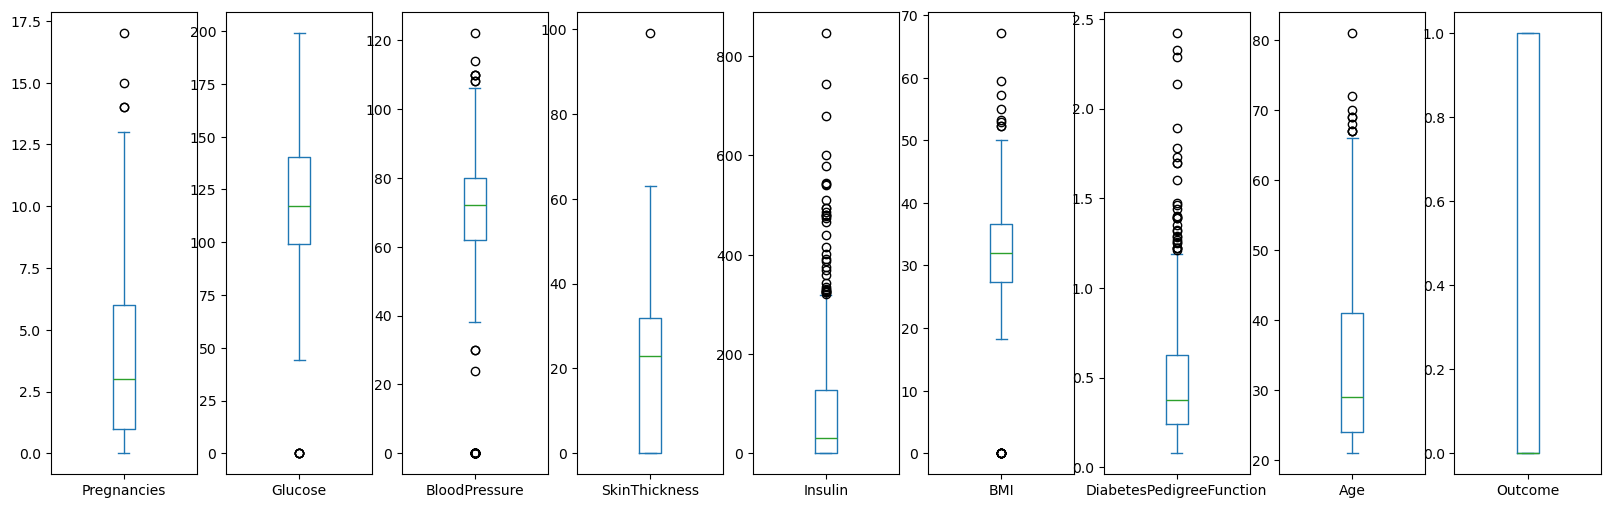

In [22]:
df.plot(kind= 'box',sharey=False,subplots=True, figsize=(20,6))

Pregnancies                    Axes(0.125,0.11;0.0731132x0.77)
Glucose                     Axes(0.212736,0.11;0.0731132x0.77)
BloodPressure               Axes(0.300472,0.11;0.0731132x0.77)
SkinThickness               Axes(0.388208,0.11;0.0731132x0.77)
Insulin                     Axes(0.475943,0.11;0.0731132x0.77)
BMI                         Axes(0.563679,0.11;0.0731132x0.77)
DiabetesPedigreeFunction    Axes(0.651415,0.11;0.0731132x0.77)
Age                         Axes(0.739151,0.11;0.0731132x0.77)
Outcome                     Axes(0.826887,0.11;0.0731132x0.77)
dtype: object

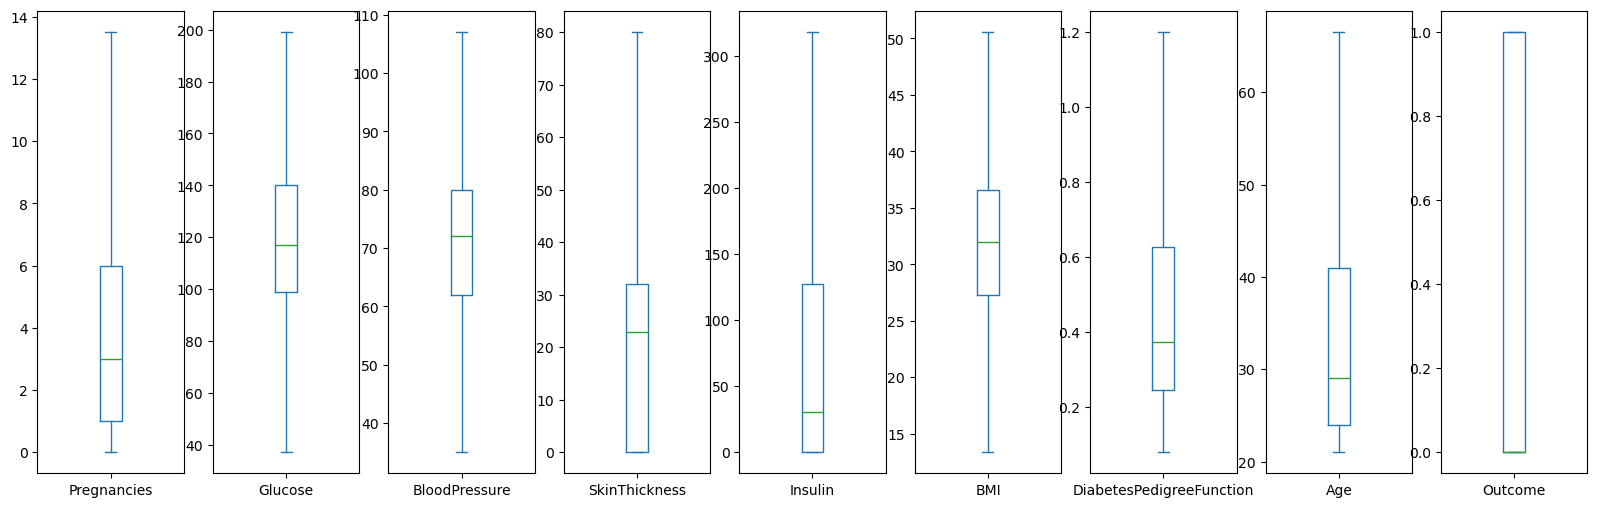

In [24]:
from feature_engine.outliers import Winsorizer
a= Winsorizer(capping_method="iqr",tail="both",fold=1.5,variables= None)
df=a.fit_transform(df)
df.plot(kind="box",subplots=True,sharey=False,figsize=(20,6))

In [28]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [32]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

y_pred = lda.predict(X_test_scaled)

In [36]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7597402597402597

Confusion Matrix:
 [[81 18]
 [19 36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



In [37]:
X_lda = lda.transform(X_train_scaled)

print("\nShape after LDA transformation:", X_lda.shape)


Shape after LDA transformation: (614, 1)


In [38]:
df.shape

(768, 9)

AUC Score: 0.8159779614325069


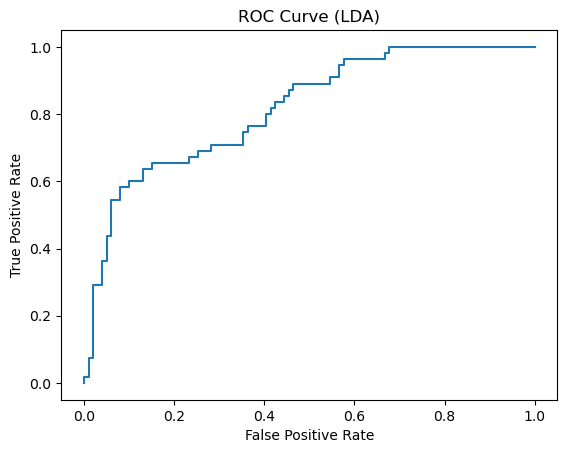

In [39]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probabilities
y_prob = lda.predict_proba(X_test_scaled)[:, 1]

# AUC Score
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LDA)")
plt.show()